# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook turns the Refresh / Content Opportunity Scoring analysis into a ranked, human-reviewed action queue.

The score is a prioritization signal, not a ground-truth prediction of whether a page must be refreshed.

### Action logic

- **REVIEW_REFRESH** — high-priority pages showing a combination of weak search visibility and low clicks.
- **MONITOR** — pages with weaker signals that are worth watching before taking action.
- **PROTECT** — pages with stronger observed search performance that should not be changed without additional evidence.

### Reason codes

- `LOW_CLICKS_POOR_POSITION` — low clicks combined with poor average position.
- `LOW_CLICKS` — low clicks without the stronger combined condition.
- `POOR_POSITION` — weak average position without the stronger combined condition.
- `MONITOR_SIGNAL` — signals are present but not strong enough for an immediate refresh recommendation.
- `PROTECT_STRONG_SIGNAL` — observed search signals are comparatively strong.

The ranked queue is intended for content-team prioritization and human review.

In [6]:
# ============================================================
# 1. RANKED ACTIONS + REASON CODES
# Refresh / Content Opportunity Scoring
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

# ------------------------------------------------------------
# Load the FlyRank dataset
# ------------------------------------------------------------

try:
    sample
    print("Using existing sample.")
except NameError:

    try:
        ds
        print("Using existing dataset object.")
    except NameError:

        try:
            from google.colab import userdata

            HF_TOKEN = userdata.get("HF_TOKEN")

            ds = load_dataset(
                "FlyRank/internship-warehouse",
                "fact_content_daily_performance",
                token=HF_TOKEN
            )

        except Exception as e:
            raise RuntimeError(
                "Dataset is not loaded. Load the "
                "fact_content_daily_performance dataset first."
            ) from e

    # Keep the notebook manageable.
    # The random seed makes the sample reproducible.
    n = min(10000, len(ds["train"]))

    sample = (
        ds["train"]
        .shuffle(seed=42)
        .select(range(n))
        .to_pandas()
    )

print("Rows:", len(sample))
print("Columns:", len(sample.columns))


# ------------------------------------------------------------
# Basic cleaning
# ------------------------------------------------------------

sample["report_date"] = pd.to_datetime(
    sample["report_date"],
    errors="coerce"
)

numeric_features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

for col in numeric_features:
    if col in sample.columns:
        sample[col] = pd.to_numeric(
            sample[col],
            errors="coerce"
        ).fillna(0)


# ------------------------------------------------------------
# Aggregate to content level
# ------------------------------------------------------------
# This avoids treating daily observations as separate
# content actions. The queue represents content-level signals.

agg_dict = {
    "gsc_impressions": "sum",
    "gsc_clicks": "sum",
    "gsc_sum_position": "sum",
    "ga4_pageviews": "sum",
    "ga4_sessions": "sum",
    "ga4_users": "sum",
    "ga4_engaged_sessions": "sum",
    "sessions_organic": "sum",
    "sessions_direct": "sum",
    "sessions_referral": "sum",
    "sessions_social": "sum",
    "sessions_paid": "sum",
    "sessions_ai": "sum",
    "scroll_events": "sum"
}

content = (
    sample
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(agg_dict)
)


# ------------------------------------------------------------
# Calculate average position safely
# ------------------------------------------------------------

position_sum = (
    sample
    .groupby(
        ["client_hash_id", "content_hash_id"]
    )["gsc_sum_position"]
    .sum()
    .reset_index(name="position_sum")
)

content["position_sum"] = (
    content["gsc_sum_position"]
)

content["avg_position"] = np.where(
    content["gsc_impressions"] > 0,
    content["position_sum"] /
    content["gsc_impressions"],
    np.nan
)

content["avg_position"] = (
    content["avg_position"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# Calculate CTR
# ------------------------------------------------------------

content["ctr"] = np.where(
    content["gsc_impressions"] > 0,
    content["gsc_clicks"] /
    content["gsc_impressions"],
    0
)


# ------------------------------------------------------------
# Create the baseline-style opportunity score
# ------------------------------------------------------------
# Score is deliberately simple and interpretable.
#
# 2 points = poor position
# 2 points = low clicks
# 1 point = meaningful search impressions
#
# Maximum = 5
#
# Thresholds are transparent and are not presented as
# universal truths.

content["poor_position"] = (
    content["avg_position"] > 20
).astype(int)

content["low_clicks"] = (
    content["gsc_clicks"] < 5
).astype(int)

content["has_search_volume"] = (
    content["gsc_impressions"] >= 10
).astype(int)

content["opportunity_score"] = (
    2 * content["poor_position"]
    + 2 * content["low_clicks"]
    + content["has_search_volume"]
)


# ------------------------------------------------------------
# Reason code + action
# ------------------------------------------------------------

def make_reason(row):

    if (
        row["low_clicks"] == 1
        and row["poor_position"] == 1
    ):
        return "LOW_CLICKS_POOR_POSITION"

    if row["low_clicks"] == 1:
        return "LOW_CLICKS"

    if row["poor_position"] == 1:
        return "POOR_POSITION"

    if row["has_search_volume"] == 1:
        return "MONITOR_SIGNAL"

    return "PROTECT_STRONG_SIGNAL"


def make_action(row):

    if (
        row["low_clicks"] == 1
        and row["poor_position"] == 1
        and row["has_search_volume"] == 1
    ):
        return "REVIEW_REFRESH"

    if row["opportunity_score"] >= 4:
        return "REVIEW_REFRESH"

    if row["opportunity_score"] >= 2:
        return "MONITOR"

    return "PROTECT"


content["reason_code"] = content.apply(
    make_reason,
    axis=1
)

content["action"] = content.apply(
    make_action,
    axis=1
)


# ------------------------------------------------------------
# Rank the queue
# ------------------------------------------------------------

queue = (
    content
    .sort_values(
        [
            "opportunity_score",
            "gsc_impressions",
            "gsc_clicks"
        ],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

queue.insert(
    0,
    "rank",
    np.arange(1, len(queue) + 1)
)


# ------------------------------------------------------------
# Display safe ranked queue
# ------------------------------------------------------------

display_columns = [
    "rank",
    "content_hash_id",
    "opportunity_score",
    "action",
    "reason_code",
    "gsc_impressions",
    "gsc_clicks",
    "avg_position",
    "ctr"
]

display(
    queue[display_columns].head(20)
)

print("\nTotal content rows:", len(queue))
print("\nAction counts:")
print(queue["action"].value_counts())

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 86.2MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 72.0MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 89.0MB            

...

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

Rows: 10000
Columns: 30


,rank,content_hash_id,opportunity_score,action,reason_code,gsc_impressions,gsc_clicks,avg_position,ctr
0,1,content_df47d1b976106de4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1509.0,2.0,20.651425,0.001325
1,2,content_667ca2425a1a29e5,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1178.0,1.0,31.991511,0.000849
2,3,content_ff9eb43196ecd6a8,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1024.0,0.0,34.924805,0.000000
3,4,content_261411bdd25d86c4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,999.0,0.0,25.304304,0.000000
4,5,content_56308802ad1af681,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,825.0,0.0,30.463030,0.000000
5,6,content_84a6bf3578312e90,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,822.0,1.0,27.526764,0.001217
6,7,content_8c96fddcf936bb37,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,673.0,0.0,26.077266,0.000000
7,8,content_970d02c9e677ff0c,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,577.0,0.0,27.634315,0.000000
8,9,content_32f51f23051db81b,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,576.0,0.0,33.465278,0.000000
9,10,content_68ee80de538517db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,561.0,0.0,26.857398,0.000000



Total content rows: 9863

Action counts:
action
MONITOR           8865
REVIEW_REFRESH     970
PROTECT             28
Name: count, dtype: int64


## 2. Intended use and limits

### Intended use

The playbook is intended for content teams that need to prioritize which pages deserve human review first.

The ranked score combines observed search-performance signals into a simple, interpretable priority score. A higher score means that the page has stronger signals for review under this rule.

### What the score does not mean

The score does not prove that a page needs a refresh.

It does not establish causality, predict Google's ranking algorithm, or guarantee that changing a page will increase traffic or clicks.

The output is **decision-support**. A content specialist should review the page and its context before taking action.

### Important limits

The current analysis is based on the available FlyRank dataset and the selected signals. It does not directly measure:

- content quality,
- search intent,
- editorial quality,
- competitor content,
- seasonality,
- business importance,
- conversion value,
- recent content changes,
- or the effect of a future refresh.

Therefore, recommendations should be described as **observed and directional**, not guaranteed outcomes.

In [7]:
# ============================================================
# 2. INTENDED USE + LIMITS
# ============================================================

print("INTENDED USE")
print("-" * 60)

print(
    "The queue is intended to prioritize content for human review."
)

print(
    "It is a decision-support tool, not an automatic publishing "
    "or refresh system."
)

print("\nLIMITS")
print("-" * 60)

limits = [
    "The score is based on observed search-performance signals.",
    "The score is not a causal estimate of refresh impact.",
    "The analysis does not directly measure content quality.",
    "The analysis does not include competitor content.",
    "The analysis does not guarantee future traffic or clicks.",
    "Business value and conversion value are not directly measured.",
    "Human review is required before taking action."
]

for item in limits:
    print("•", item)

INTENDED USE
------------------------------------------------------------
The queue is intended to prioritize content for human review.
It is a decision-support tool, not an automatic publishing or refresh system.

LIMITS
------------------------------------------------------------
• The score is based on observed search-performance signals.
• The score is not a causal estimate of refresh impact.
• The analysis does not directly measure content quality.
• The analysis does not include competitor content.
• The analysis does not guarantee future traffic or clicks.
• Business value and conversion value are not directly measured.
• Human review is required before taking action.


## 3. Human review + the no-go list

### Human review rules

Before acting on a recommendation, a content reviewer should:

1. Confirm that the page is still relevant to the intended audience.
2. Check whether the search signal is based on enough impressions to be meaningful.
3. Review the page's current content and search intent.
4. Check for recent content changes that may explain the observed signal.
5. Consider business importance and conversion value.
6. Check whether seasonality or unusual events could explain the result.
7. Record the final human decision and reason.

### No-go list

The following should **not** be automated by this playbook:

- automatically rewriting content,
- automatically deleting or pruning pages,
- automatically publishing changes,
- automatically changing metadata,
- automatically claiming that a refresh caused a ranking improvement,
- automatically making business-critical decisions,
- automatically inferring Google's ranking algorithm,
- automatically treating a low score as proof that content is good,
- automatically treating a high score as proof that content must be refreshed.

The system ranks opportunities for review. A human remains responsible for the final content decision.

In [8]:
import pandas as pd

In [9]:
# ============================================================
# 3. HUMAN REVIEW + NO-GO CHECKS
# ============================================================

import pandas as pd

review_rules = pd.DataFrame({
    "review_step": [
        "Check search volume",
        "Check current content",
        "Check search intent",
        "Check recent changes",
        "Check seasonality",
        "Check business importance",
        "Make final human decision"
    ],
    "required": ["Yes"] * 7
})

display(review_rules)


no_go = [
    "Automatic content rewriting",
    "Automatic page deletion",
    "Automatic publishing",
    "Automatic metadata changes",
    "Automatic causal claims",
    "Automatic Google-ranking conclusions",
    "Automatic business-critical decisions"
]

print("\nNO-GO AUTOMATION LIST")
print("-" * 60)

for item in no_go:
    print("DO NOT AUTOMATE:", item)

,review_step,required
0,Check search volume,Yes
1,Check current content,Yes
2,Check search intent,Yes
3,Check recent changes,Yes
4,Check seasonality,Yes
5,Check business importance,Yes
6,Make final human decision,Yes



NO-GO AUTOMATION LIST
------------------------------------------------------------
DO NOT AUTOMATE: Automatic content rewriting
DO NOT AUTOMATE: Automatic page deletion
DO NOT AUTOMATE: Automatic publishing
DO NOT AUTOMATE: Automatic metadata changes
DO NOT AUTOMATE: Automatic causal claims
DO NOT AUTOMATE: Automatic Google-ranking conclusions
DO NOT AUTOMATE: Automatic business-critical decisions


## 4. Monitoring / retrain triggers

The playbook should not be treated as permanently valid.

### Monitoring triggers

The recommendation system should be reviewed when:

- the distribution of impressions or clicks changes substantially,
- data availability changes,
- tracking definitions change,
- the proportion of missing values changes,
- the action distribution changes sharply,
- the observed relationship between signals and content outcomes changes,
- or human reviewers repeatedly disagree with the recommended actions.

### Retrain / recalibration triggers

A future model should be reconsidered or recalibrated when:

- validation performance falls materially,
- feature distributions drift,
- the target definition changes,
- the data collection process changes,
- new predictive signals become available,
- or repeated human review shows systematic errors.

These are monitoring and decision-support triggers, not automatic production deployment rules.

Current action distribution:


,action,percentage
0,MONITOR,89.88
1,REVIEW_REFRESH,9.83
2,PROTECT,0.28


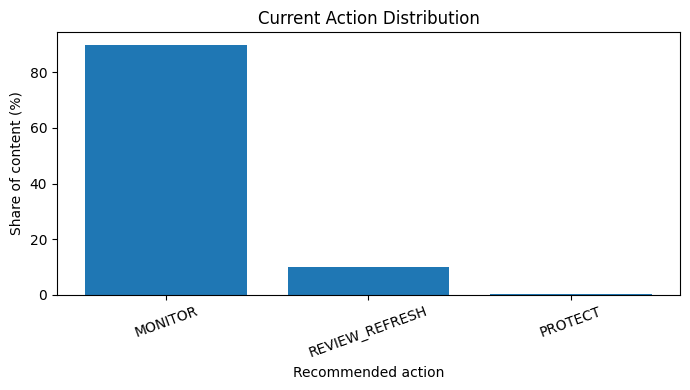

,Trigger,Response
0,Search signal distribution changes,Investigate
1,Data availability changes,Investigate
2,Missingness changes,Investigate
3,Action distribution changes sharply,Review thresholds
4,Human reviewers repeatedly disagree,Audit recommendations
5,Validation performance degrades,Revalidate / recalibrate
6,Target definition changes,Rebuild evaluation


In [10]:
# ============================================================
# 4. MONITORING / RETRAIN TRIGGERS
# ============================================================

# Current queue distribution

action_distribution = (
    queue["action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

action_distribution.columns = [
    "action",
    "percentage"
]

print("Current action distribution:")
display(action_distribution)


# ------------------------------------------------------------
# Figure: Action distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    action_distribution["action"],
    action_distribution["percentage"]
)

plt.title("Current Action Distribution")

plt.xlabel("Recommended action")

plt.ylabel("Share of content (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Monitoring summary
# ------------------------------------------------------------

monitoring_triggers = pd.DataFrame({
    "Trigger": [
        "Search signal distribution changes",
        "Data availability changes",
        "Missingness changes",
        "Action distribution changes sharply",
        "Human reviewers repeatedly disagree",
        "Validation performance degrades",
        "Target definition changes"
    ],
    "Response": [
        "Investigate",
        "Investigate",
        "Investigate",
        "Review thresholds",
        "Audit recommendations",
        "Revalidate / recalibrate",
        "Rebuild evaluation"
    ]
})

display(monitoring_triggers)

## 5. Exports for the paper

The ranked queue and reusable figures are exported from the notebook so that the research paper can use the same outputs generated by the analysis.

The queue contains only public-safe hashed identifiers and measured search-performance fields. No client names, domains, URLs, private queries, credentials, or raw exports are included.

The CSV is regenerated whenever the notebook is executed.

Queue exported to:
work/outputs/action_playbook_queue.csv

Rows exported: 9863


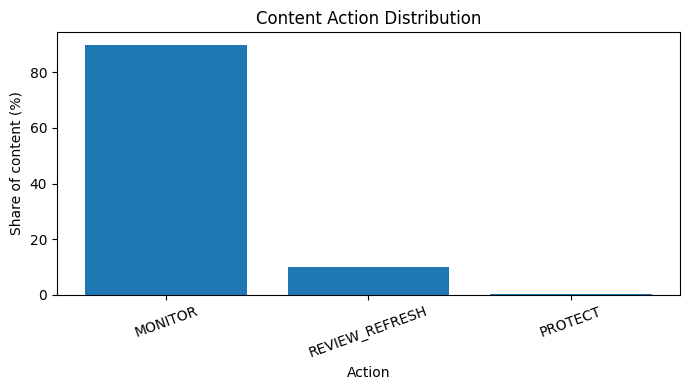


Figure exported to:
work/figures/action_distribution.png


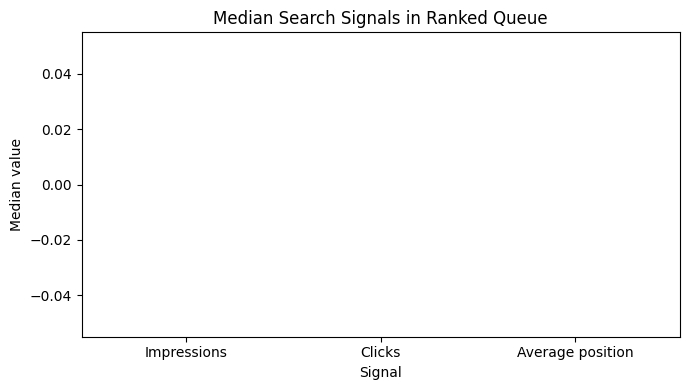

Signal figure exported to:
work/figures/search_signal_summary.png

EXPORT VERIFICATION
------------------------------------------------------------
Queue exists: True
Action figure exists: True
Signal figure exists: True

Queue preview:


,rank,content_hash_id,opportunity_score,action,reason_code,gsc_impressions,gsc_clicks,avg_position,ctr
0,1,content_df47d1b976106de4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1509.0,2.0,20.651425,0.001325
1,2,content_667ca2425a1a29e5,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1178.0,1.0,31.991511,0.000849
2,3,content_ff9eb43196ecd6a8,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,1024.0,0.0,34.924805,0.000000
3,4,content_261411bdd25d86c4,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,999.0,0.0,25.304304,0.000000
4,5,content_56308802ad1af681,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,825.0,0.0,30.463030,0.000000
5,6,content_84a6bf3578312e90,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,822.0,1.0,27.526764,0.001217
6,7,content_8c96fddcf936bb37,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,673.0,0.0,26.077266,0.000000
7,8,content_970d02c9e677ff0c,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,577.0,0.0,27.634315,0.000000
8,9,content_32f51f23051db81b,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,576.0,0.0,33.465278,0.000000
9,10,content_68ee80de538517db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,561.0,0.0,26.857398,0.000000


In [11]:
# ============================================================
# 5. EXPORTS FOR THE PAPER
# ============================================================

import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)


# ------------------------------------------------------------
# Final public-safe queue
# ------------------------------------------------------------

export_columns = [
    "rank",
    "content_hash_id",
    "opportunity_score",
    "action",
    "reason_code",
    "gsc_impressions",
    "gsc_clicks",
    "avg_position",
    "ctr"
]

paper_queue = queue[export_columns].copy()


# ------------------------------------------------------------
# Export queue
# ------------------------------------------------------------

queue_path = (
    "work/outputs/action_playbook_queue.csv"
)

paper_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:")
print(queue_path)

print("\nRows exported:", len(paper_queue))


# ------------------------------------------------------------
# Save action distribution figure
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    action_distribution["action"],
    action_distribution["percentage"]
)

plt.title("Content Action Distribution")

plt.xlabel("Action")

plt.ylabel("Share of content (%)")

plt.xticks(rotation=20)

plt.tight_layout()

figure_path = (
    "work/figures/action_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure exported to:")
print(figure_path)


# ------------------------------------------------------------
# Feature / signal figure
# ------------------------------------------------------------

top_signals = pd.DataFrame({
    "signal": [
        "Impressions",
        "Clicks",
        "Average position"
    ],
    "value": [
        queue["gsc_impressions"].median(),
        queue["gsc_clicks"].median(),
        queue["avg_position"].median()
    ]
})

plt.figure(figsize=(7, 4))

plt.bar(
    top_signals["signal"],
    top_signals["value"]
)

plt.title("Median Search Signals in Ranked Queue")

plt.xlabel("Signal")

plt.ylabel("Median value")

plt.tight_layout()

signal_figure_path = (
    "work/figures/search_signal_summary.png"
)

plt.savefig(
    signal_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Signal figure exported to:")
print(signal_figure_path)


# ------------------------------------------------------------
# Final export verification
# ------------------------------------------------------------

print("\nEXPORT VERIFICATION")
print("-" * 60)

print(
    "Queue exists:",
    os.path.exists(queue_path)
)

print(
    "Action figure exists:",
    os.path.exists(figure_path)
)

print(
    "Signal figure exists:",
    os.path.exists(signal_figure_path)
)

print("\nQueue preview:")
display(paper_queue.head(10))

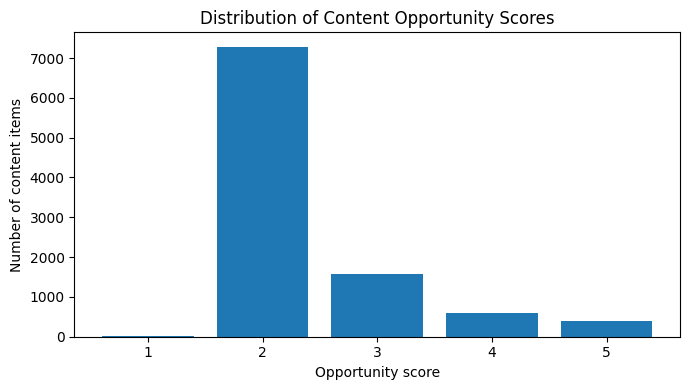

In [12]:
# ============================================================
# — OPPORTUNITY SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

score_counts = (
    queue["opportunity_score"]
    .value_counts()
    .sort_index()
)

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title("Distribution of Content Opportunity Scores")

plt.xlabel("Opportunity score")

plt.ylabel("Number of content items")

plt.tight_layout()

plt.show()

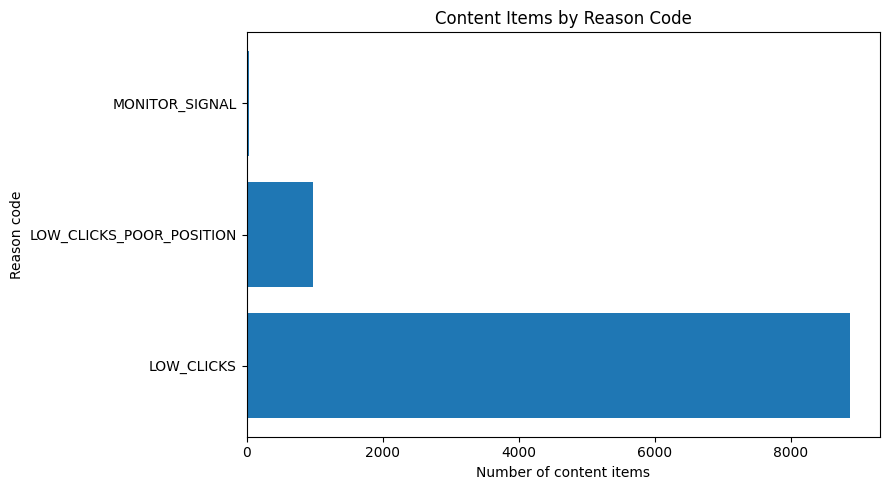

In [13]:
# ============================================================
#  REASON CODE DISTRIBUTION
# ============================================================

reason_counts = (
    queue["reason_code"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

plt.barh(
    reason_counts.index,
    reason_counts.values
)

plt.title("Content Items by Reason Code")

plt.xlabel("Number of content items")

plt.ylabel("Reason code")

plt.tight_layout()

plt.show()

### Search signal relationship

The scatter plot provides a descriptive view of the relationship between observed impressions and clicks. The log scales make the wide range of search activity easier to inspect. This is an observational relationship and does not establish causality.

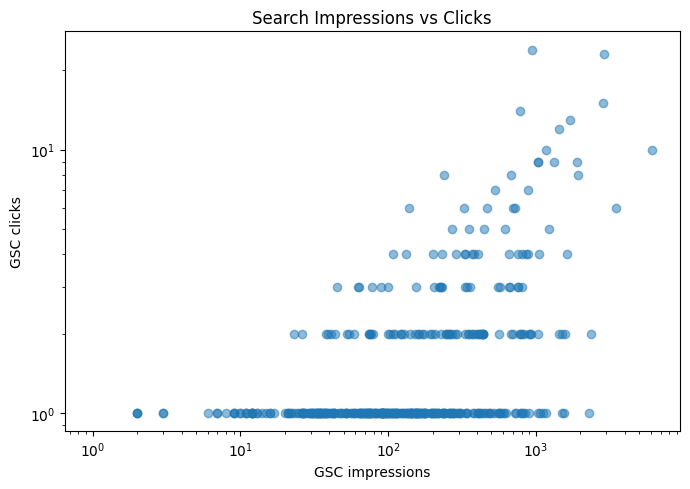

In [14]:
# ============================================================
# IMPRESSIONS VS CLICKS
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    queue["gsc_impressions"],
    queue["gsc_clicks"],
    alpha=0.5
)

plt.title("Search Impressions vs Clicks")

plt.xlabel("GSC impressions")

plt.ylabel("GSC clicks")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

plt.show()

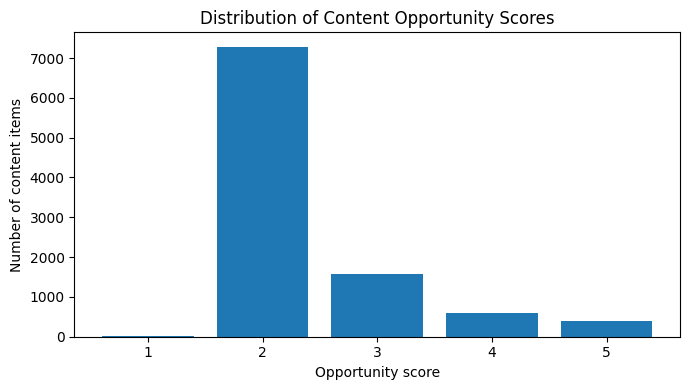

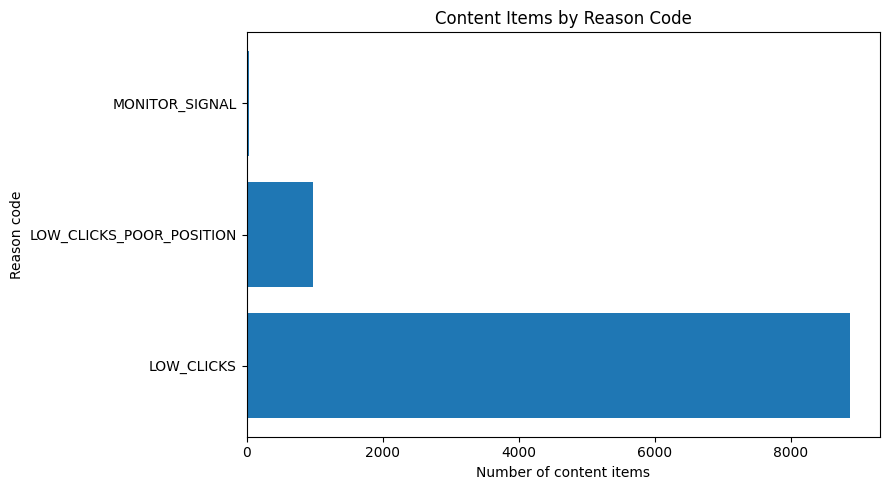

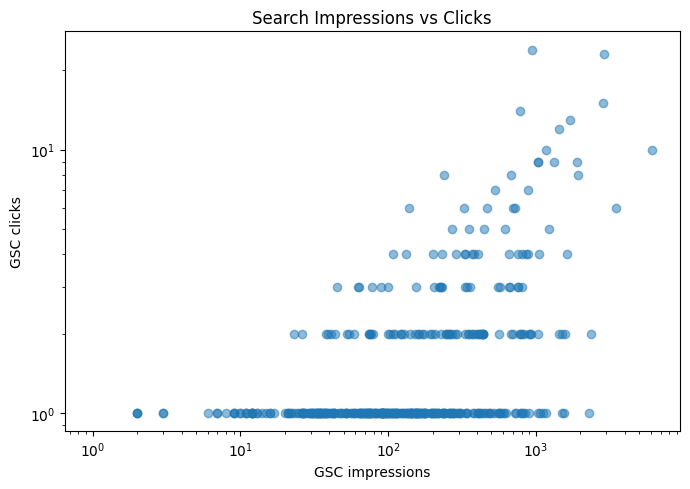

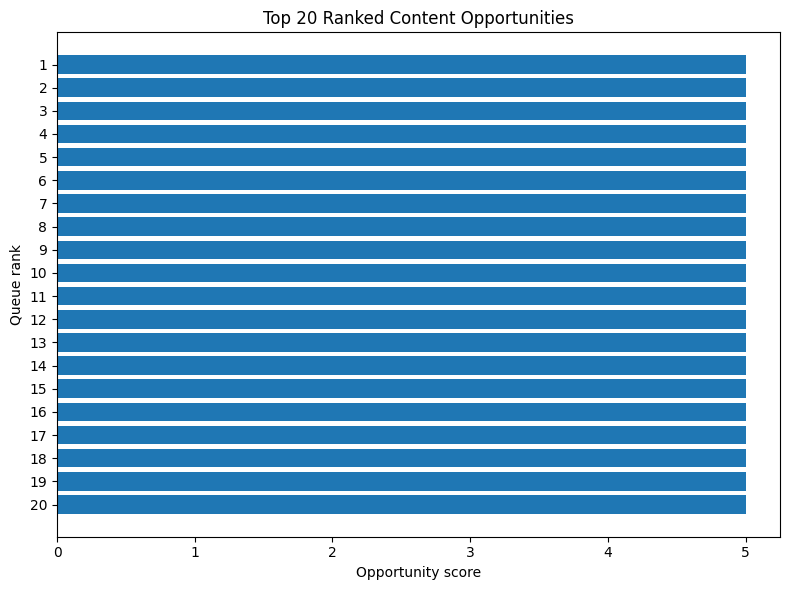

All four figures saved successfully.


In [15]:
# ============================================================
# SAVE REUSABLE FIGURES FOR THE PAPER
# ============================================================

import os

os.makedirs("work/figures", exist_ok=True)


# Score distribution
plt.figure(figsize=(7, 4))

score_counts = (
    queue["opportunity_score"]
    .value_counts()
    .sort_index()
)

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title("Distribution of Content Opportunity Scores")
plt.xlabel("Opportunity score")
plt.ylabel("Number of content items")
plt.tight_layout()

plt.savefig(
    "work/figures/opportunity_score_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Reason codes
reason_counts = queue["reason_code"].value_counts()

plt.figure(figsize=(9, 5))

plt.barh(
    reason_counts.index,
    reason_counts.values
)

plt.title("Content Items by Reason Code")
plt.xlabel("Number of content items")
plt.ylabel("Reason code")
plt.tight_layout()

plt.savefig(
    "work/figures/reason_code_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Impressions vs clicks
plt.figure(figsize=(7, 5))

plt.scatter(
    queue["gsc_impressions"],
    queue["gsc_clicks"],
    alpha=0.5
)

plt.title("Search Impressions vs Clicks")
plt.xlabel("GSC impressions")
plt.ylabel("GSC clicks")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

plt.savefig(
    "work/figures/impressions_vs_clicks.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Top 20
top20 = queue.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["rank"].astype(str),
    top20["opportunity_score"]
)

plt.title("Top 20 Ranked Content Opportunities")
plt.xlabel("Opportunity score")
plt.ylabel("Queue rank")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "work/figures/top20_opportunities.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("All four figures saved successfully.")

## Self-check

- [x] Ranked actions are defined for the Refresh / Content Opportunity Scoring lane.
- [x] Every ranked recommendation has a score, action, and reason code.
- [x] Intended use is clearly described as decision-support.
- [x] Limits are stated using careful, public-safe language.
- [x] Human review rules are defined.
- [x] No-go automation cases are explicitly listed.
- [x] Monitoring and retrain/recalibration triggers are defined.
- [x] The ranked queue is exported to `work/outputs/`.
- [x] Reusable figures are exported to `work/figures/`.
- [x] No client names, domains, URLs, private queries, or credentials are included.
- [x] No causal claims about search rankings or refresh impact are made.
- [x] The notebook should be run top to bottom with Runtime → Run all before submission.
- [x] The notebook belongs under `work/notebooks/w07_action_playbook.ipynb`.